# Para a semana 2, faremos mais alguns tratamentos da base de dados e prepararemos para aplicar em um modelo de Machine Learning de Regressão.

In [ ]:
import zipfile
import os
import requests

# Caminho do arquivo ZIP
zip_url = "https://caelum-online-public.s3.amazonaws.com/challenge-spark/semana-2.zip"
zip_path = "/home/luizh/Python/1Challenge/Data Science/Alura-Challenge-DS/Semanas_zip/semana-2.zip"
extract_path = "/home/luizh/Python/1Challenge/Data Science/Alura-Challenge-DS/Dataset"

# Baixar o arquivo ZIP
response = requests.get(zip_url)
with open(zip_path, "wb") as f:
    f.write(response.content)

# Extrair o conteúdo
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Listar os arquivos extraídos
os.listdir(extract_path)

['dataset_transformado_parquet']

In [ ]:
from pyspark.sql import SparkSession

# Inicializar o Spark
spark = SparkSession.builder.appName("ProcessamentoParquet").getOrCreate()

# Caminho do arquivo PARQUET
parquet_path = "/home/luizh/Python/1Challenge/Data Science/Alura-Challenge-DS/Dataset/dataset_transformado_parquet"  # Substitua pelo nome real do arquivo

# Carregar o arquivo JSON em um DataFrame
df = spark.read.parquet(parquet_path)

# Exibir as primeiras linhas
df.show(10)

+--------------------+-----+----------+---------+---------+--------------------+-------+------+------------+------------+-----------+----+--------------------+------------+----------+----+-----+------+
|                  id|andar|area_total|area_util|banheiros|     caracteristicas|quartos|suites|tipo_anuncio|tipo_unidade|   tipo_uso|vaga|              bairro|        zona|condominio|iptu| tipo| valor|
+--------------------+-----+----------+---------+---------+--------------------+-------+------+------------+------------+-----------+----+--------------------+------------+----------+----+-----+------+
|03a386b6-7ab8-4ef...|    0|        43|       43|        1|[Churrasqueira, A...|      2|  NULL|       Usado| Apartamento|Residencial|   1|            Realengo|  Zona Oeste|       285|NULL|Venda| 22999|
|1fe78d41-b8e0-4d2...|    0|        44|       44|        1|                  []|      2|     0|       Usado| Apartamento|Residencial|   0|               Irajá|  Zona Norte|       170|   0|Vend

# Para começar deixaremos somente features importantes, isto é colunas que vão ser úteis para o nosso modelo de Machine Learning. Logo estaremos retirando as colunas de `id`, `tipo_anuncio`, `tipo_unidade`, `tipo_uso` e `tipo`, sendo esta colunas tendo sido filtradas na semana 1.



In [4]:
df = df.drop('id')
df = df.drop('tipo_anuncio')
df = df.drop('tipo_unidade')
df = df.drop('tipo_uso')
df = df.drop('tipo')

df.show(5)

+-----+----------+---------+---------+--------------------+-------+------+----+------------+------------+----------+----+------+
|andar|area_total|area_util|banheiros|     caracteristicas|quartos|suites|vaga|      bairro|        zona|condominio|iptu| valor|
+-----+----------+---------+---------+--------------------+-------+------+----+------------+------------+----------+----+------+
|    0|        43|       43|        1|[Churrasqueira, A...|      2|  NULL|   1|    Realengo|  Zona Oeste|       285|NULL| 22999|
|    0|        44|       44|        1|                  []|      2|     0|   0|       Irajá|  Zona Norte|       170|   0|110000|
|    4|      NULL|       55|        1|                  []|      2|     0|   1|      Cosmos|  Zona Oeste|      NULL|NULL|115000|
|    2|      NULL|       55|        1|                  []|      2|     0|   0|Tomás Coelho|  Zona Norte|      NULL|NULL|115000|
|    0|      NULL|       50|        1|                  []|      1|  NULL|   0|      Centro|Zona 

## Percebe que as colunas `area_total` e `area_util`, possuem em muitas linhas valores iguais, analisaremos estas colunas para ver o quanto se diferem

In [5]:
df.select('*').where(df['area_total'] != df['area_util']).count()

1984

In [6]:
df.count()

66562

In [7]:
# Conta a quantidade de dados não nulos da coluna area_total
df.select('area_total').na.drop().count()

57368

In [8]:
# Conta a quantidade de dados não nulos da coluna area_util
df.select('area_util').na.drop().count()

66562

## E como é perceptível, apenas 1984 linhas de 66562 linhas são diferentes e o resto é dado nulo, logo tiraremos a colunas `area_total` e ficaremos apenas com a coluna `area_util` como feature.

In [9]:
df = df.drop('area_total')
df.show(5)

+-----+---------+---------+--------------------+-------+------+----+------------+------------+----------+----+------+
|andar|area_util|banheiros|     caracteristicas|quartos|suites|vaga|      bairro|        zona|condominio|iptu| valor|
+-----+---------+---------+--------------------+-------+------+----+------------+------------+----------+----+------+
|    0|       43|        1|[Churrasqueira, A...|      2|  NULL|   1|    Realengo|  Zona Oeste|       285|NULL| 22999|
|    0|       44|        1|                  []|      2|     0|   0|       Irajá|  Zona Norte|       170|   0|110000|
|    4|       55|        1|                  []|      2|     0|   1|      Cosmos|  Zona Oeste|      NULL|NULL|115000|
|    2|       55|        1|                  []|      2|     0|   0|Tomás Coelho|  Zona Norte|      NULL|NULL|115000|
|    0|       50|        1|                  []|      1|  NULL|   0|      Centro|Zona Central|      1300|2679|125000|
+-----+---------+---------+--------------------+-------+

In [10]:
df.printSchema()

root
 |-- andar: long (nullable = true)
 |-- area_util: string (nullable = true)
 |-- banheiros: long (nullable = true)
 |-- caracteristicas: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- quartos: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- vaga: long (nullable = true)
 |-- bairro: string (nullable = true)
 |-- zona: string (nullable = true)
 |-- condominio: string (nullable = true)
 |-- iptu: string (nullable = true)
 |-- valor: string (nullable = true)



# Ao analisarmos a estrutura da nossa base de dados, vamos notar que os tipos dos dados de cada coluna estão incorretos e por isso é necessário convertê-los.

# Nisso converteremos o tipo de colunas numéricas, como "andar", "banheiros", "suites" e "quartos" para o tipo inteiro. Além disso também pode ser necessário converter as colunas "area_util", "condominio", "iptu" e "valor" para o tipo double.

In [11]:
from pyspark.sql.types import IntegerType, DoubleType

# Converte colunas para o tipo inteiro
df = df.withColumn("andar", df["andar"].cast(IntegerType()))
df = df.withColumn("banheiros", df["banheiros"].cast(IntegerType()))
df = df.withColumn("suites", df["suites"].cast(IntegerType()))
df = df.withColumn("quartos", df["quartos"].cast(IntegerType()))

# Converte colunas para o tipo double
df = df.withColumn("area_util", df["area_util"].cast(DoubleType()))
df = df.withColumn("condominio", df["condominio"].cast(DoubleType()))
df = df.withColumn("iptu", df["iptu"].cast(DoubleType()))
df = df.withColumn("valor", df["valor"].cast(DoubleType()))

df.printSchema()

root
 |-- andar: integer (nullable = true)
 |-- area_util: double (nullable = true)
 |-- banheiros: integer (nullable = true)
 |-- caracteristicas: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- quartos: integer (nullable = true)
 |-- suites: integer (nullable = true)
 |-- vaga: long (nullable = true)
 |-- bairro: string (nullable = true)
 |-- zona: string (nullable = true)
 |-- condominio: double (nullable = true)
 |-- iptu: double (nullable = true)
 |-- valor: double (nullable = true)



# A coluna caracteristicas possui listas de strings como conteúdo de suas linhas. No entanto, algumas dessas listas estão sem elementos.

# Vamos transformar essas listas sem elementos em valores nulos.

In [12]:
import pyspark.sql.functions as f

In [13]:
df = df.withColumn('caracteristicas', f.when(f.size(df.caracteristicas) == 0, None).otherwise(df.caracteristicas))
df.show()

+-----+---------+---------+--------------------+-------+------+----+--------------------+------------+----------+------+--------+
|andar|area_util|banheiros|     caracteristicas|quartos|suites|vaga|              bairro|        zona|condominio|  iptu|   valor|
+-----+---------+---------+--------------------+-------+------+----+--------------------+------------+----------+------+--------+
|    0|     43.0|        1|[Churrasqueira, A...|      2|  NULL|   1|            Realengo|  Zona Oeste|     285.0|  NULL| 22999.0|
|    0|     44.0|        1|                NULL|      2|     0|   0|               Irajá|  Zona Norte|     170.0|   0.0|110000.0|
|    4|     55.0|        1|                NULL|      2|     0|   1|              Cosmos|  Zona Oeste|      NULL|  NULL|115000.0|
|    2|     55.0|        1|                NULL|      2|     0|   0|        Tomás Coelho|  Zona Norte|      NULL|  NULL|115000.0|
|    0|     50.0|        1|                NULL|      1|  NULL|   0|              Centro|Z

# Ao analisarmos a estrutura da nossa base de dados, vamos notar que ela possui diversos dados faltantes. Dessa maneira, é importante lidarmos com isso, pois modelos de Machine Learning não costumam trabalhar corretamente com dados nulos.

# Além do mais, as colunas `caracteristicas` e `zona`, não está adequada para o modelo, vamos expander e transformar em colunas booleanas.



In [14]:
df.select('bairro').distinct().toPandas().tail(5)

,bairro
149,Jardim América
150,São Conrado
151,São Cristóvão
152,Benfica
153,Cavalcanti


In [15]:
df.select('zona').distinct().show()

+------------+
|        zona|
+------------+
|  Zona Norte|
|  Zona Oeste|
|Zona Central|
|    Zona Sul|
|            |
+------------+



In [16]:
df_valor_nulo = df.select('zona').distinct().toPandas().iloc[-1,0]

df = df.select('*').where(df['zona'] != df_valor_nulo)
df.select('zona').distinct().show()

+------------+
|        zona|
+------------+
|  Zona Norte|
|  Zona Oeste|
|Zona Central|
|    Zona Sul|
+------------+



In [17]:
df.count()

66551

## Como visto, de 66562 linhas com `zona` com valor nulo apenas 1 tinha, logo retirar não será um problema. Segue em seguida a análise da colunas numéricas.

In [18]:
df.select('andar').summary().show()

+-------+------------------+
|summary|             andar|
+-------+------------------+
|  count|             66551|
|   mean| 2.337771032741807|
| stddev|14.697532590089427|
|    min|                 0|
|    25%|                 0|
|    50%|                 0|
|    75%|                 3|
|    max|              1234|
+-------+------------------+



In [19]:
df.select('banheiros').summary().show()

+-------+------------------+
|summary|         banheiros|
+-------+------------------+
|  count|             66551|
|   mean|2.4546438070051537|
| stddev| 1.358264030677201|
|    min|                 1|
|    25%|                 2|
|    50%|                 2|
|    75%|                 3|
|    max|                19|
+-------+------------------+



In [20]:
df.select('quartos').summary().show()

+-------+------------------+
|summary|           quartos|
+-------+------------------+
|  count|             66551|
|   mean| 2.612192153386125|
| stddev|0.9084135268636037|
|    min|                 0|
|    25%|                 2|
|    50%|                 3|
|    75%|                 3|
|    max|                16|
+-------+------------------+



In [21]:
df.select('suites').summary().show()

+-------+------------------+
|summary|            suites|
+-------+------------------+
|  count|             61000|
|   mean|1.2091475409836066|
| stddev|1.0567876818285364|
|    min|                 0|
|    25%|                 1|
|    50%|                 1|
|    75%|                 1|
|    max|                30|
+-------+------------------+



In [22]:
df.select('vaga').summary().show()

+-------+------------------+
|summary|              vaga|
+-------+------------------+
|  count|             63538|
|   mean|1.4068588875948251|
| stddev|1.3413515314365996|
|    min|                 0|
|    25%|                 1|
|    50%|                 1|
|    75%|                 2|
|    max|                99|
+-------+------------------+



In [23]:
df.select('condominio').summary().show()

+-------+------------------+
|summary|        condominio|
+-------+------------------+
|  count|             64180|
|   mean| 4823.374088501091|
| stddev|106058.77886489475|
|    min|               0.0|
|    25%|             462.0|
|    50%|             894.0|
|    75%|            1480.0|
|    max|             1.1E7|
+-------+------------------+



In [24]:
df.select('iptu').summary().show()

+-------+------------------+
|summary|              iptu|
+-------+------------------+
|  count|             59355|
|   mean| 5448.364855530284|
| stddev|181204.96294007008|
|    min|               0.0|
|    25%|              54.0|
|    50%|             360.0|
|    75%|            1849.0|
|    max|             2.0E7|
+-------+------------------+



In [25]:
df.select('valor').summary().show()

+-------+------------------+
|summary|             valor|
+-------+------------------+
|  count|             66551|
|   mean|1294449.7203197547|
| stddev|1471795.9437955515|
|    min|           15000.0|
|    25%|          455000.0|
|    50%|          808600.0|
|    75%|         1540000.0|
|    max|            1.39E7|
+-------+------------------+



## Antes de tratamos os dados nulos, nota-se que algumas linhas aparentam estar com valores errados ou que são dados fora da média maioria dos outros, analisaremos e então preencheremos dados nulos e decidiremos o que faremos com esses resultados.

In [26]:
# Winsorização para teste
import numpy as np
import pandas as pd
from scipy.stats.mstats import winsorize

def winsorizacao(df, coluna):
  intervalo = np.array(df.select(coluna).toPandas())
  valores = winsorize(intervalo, limits=[0.05, 0.05])

  df_valores = pd.DataFrame(valores, columns=[coluna])
  print(df_valores.describe())

In [27]:
winsorizacao(df, 'condominio')

         condominio
count  66551.000000
mean    1258.255083
std     1252.329143
min        0.000000
25%      492.000000
50%      901.000000
75%     1550.000000
max     5100.000000


In [28]:
df = df.fillna({'condominio': 901.0})

In [29]:
winsorizacao(df, 'suites')

             suites
count  61000.000000
mean       1.209148
std        1.056788
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       30.000000


In [30]:
df = df.fillna({'suites': 1})

In [31]:
winsorizacao(df, 'vaga')

               vaga
count  66551.000000
mean       1.541780
std        1.169006
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000


In [32]:
df = df.fillna({'vaga': 1})

Seguindo a regra de iptu, para dados nulos nesta coluna, vamos reescrevê-la conforme sua regra

In [33]:
df = df.withColumn('iptu', f.when(df['iptu']>0, df['iptu']).otherwise(df['valor']*0.01))

## Algumas linhas

In [34]:
print(df.select('*').where((df['iptu'] > df['valor']*0.01) | (df['condominio'] > 4500)).count())
df.select('*').where((df['iptu'] > df['valor']*0.01) | (df['condominio'] > 4500)).show()

1562
+-----+---------+---------+--------------------+-------+------+----+---------------+------------+----------+-------+---------+
|andar|area_util|banheiros|     caracteristicas|quartos|suites|vaga|         bairro|        zona|condominio|   iptu|    valor|
+-----+---------+---------+--------------------+-------+------+----+---------------+------------+----------+-------+---------+
|    0|     50.0|        1|                NULL|      1|     1|   0|         Centro|Zona Central|    1300.0| 2679.0| 125000.0|
|    0|     70.0|        2|   [Salão de festas]|      2|     0|   1|     Praça Seca|  Zona Oeste|  420000.0| 1590.0| 159000.0|
|    0|    100.0|        3|[Piscina, Playgro...|      2|     1|   1|        Ipanema|    Zona Sul|    5000.0| 7840.0|2000000.0|
|    4|    108.0|        2|[Portão eletrônic...|      3|     1|   1|         Leblon|    Zona Sul|   23473.0| 4224.0|2200000.0|
|    0|    525.0|        4|                NULL|      4|     2|   2|       Flamengo|    Zona Sul|    5000.

In [35]:
print(df.select('*').where(df['suites'] >= 7).count())
df.select('*').where(df['suites'] >= 7).show()

9
+-----+---------+---------+--------------------+-------+------+----+--------------------+----------+----------+------+---------+
|andar|area_util|banheiros|     caracteristicas|quartos|suites|vaga|              bairro|      zona|condominio|  iptu|    valor|
+-----+---------+---------+--------------------+-------+------+----+--------------------+----------+----------+------+---------+
|    0|    210.0|        2|[Elevador, Portão...|      4|    20|   3|              Leblon|  Zona Sul|     111.0| 111.0|6000000.0|
|    0|    159.0|        4|[Academia, Piscin...|      4|    12|   1|     Barra da Tijuca|Zona Oeste|    2016.0| 480.0|1850000.0|
|    1|    620.0|        8|                NULL|      7|     7|   3|            Flamengo|  Zona Sul|    3500.0|1900.0|5500000.0|
|    4|    214.0|        4|[Elevador, Condom...|      4|    21|   2|            Flamengo|  Zona Sul|    2065.0| 590.0|2300000.0|
|    3|     75.0|        1|[Playground, Salã...|      2|    30|   1|              Tijuca|Zona N

In [36]:
print(df.select('*').where(df['vaga'] >= 8).count())
df.select('*').where(df['vaga'] >= 8).show()

129
+-----+---------+---------+--------------------+-------+------+----+--------------------+----------+----------+-------+---------+
|andar|area_util|banheiros|     caracteristicas|quartos|suites|vaga|              bairro|      zona|condominio|   iptu|    valor|
+-----+---------+---------+--------------------+-------+------+----+--------------------+----------+----------+-------+---------+
|    0|     84.0|        2|                NULL|      3|     1|  12|Recreio dos Bande...|Zona Oeste|    1200.0|  250.0| 630000.0|
|    3|    320.0|        5|[Elevador, Churra...|      4|     2|  32|Recreio dos Bande...|Zona Oeste|    1350.0| 6525.0|2298000.0|
|    0|    211.0|        3|                NULL|      4|     2|  21|Freguesia (Jacare...|Zona Oeste|       0.0|11800.0|1180000.0|
|    0|     83.0|        2|[Animais permitidos]|      3|     1|   8|Recreio dos Bande...|Zona Oeste|       0.0| 6600.0| 660000.0|
|    0|    165.0|        3|[Academia, Churra...|      4|     2|  16|     Barra da Tiju

In [37]:
df = df.select('*').where((df['iptu'] <= df['valor']*0.01) & (df['condominio'] <= 4500))
df = df.select('*').where(df['suites'] <= 7)
df = df.select('*').where(df['vaga'] <= 8)

df.count()

64891

## Tratado dos valores nulos e outros dados, faremos uma expansão da coluna `caracteristicas` e da coluna `zona`

In [38]:
caracteristicas = df.select('caracteristicas')
caracteristicas = caracteristicas.withColumn('explode', f.explode(caracteristicas['caracteristicas']))

dados = caracteristicas.select('explode').distinct().collect()
partes = [elemento['explode'] for elemento in dados]

for coluna in partes:
  df = df.withColumn(coluna, f.when(f.array_contains(df['caracteristicas'], coluna), 1).otherwise(0))

df = df.drop('caracteristicas')
df.show(5)

+-----+---------+---------+-------+------+----+------------+----------+----------+------+--------+------------------+----------+-----------------+-------+------------------+------------+--------+--------+---------------+-------------+
|andar|area_util|banheiros|quartos|suites|vaga|      bairro|      zona|condominio|  iptu|   valor|Condomínio fechado|Playground|Portão eletrônico|Piscina|Animais permitidos|Portaria 24h|Elevador|Academia|Salão de festas|Churrasqueira|
+-----+---------+---------+-------+------+----+------------+----------+----------+------+--------+------------------+----------+-----------------+-------+------------------+------------+--------+--------+---------------+-------------+
|    0|     43.0|        1|      2|     1|   1|    Realengo|Zona Oeste|     285.0|229.99| 22999.0|                 1|         1|                1|      0|                 1|           1|       0|       1|              1|            1|
|    0|     44.0|        1|      2|     0|   0|       Irajá|

In [39]:
dados = df.select('zona').distinct().collect()
partes = [elemento['zona'] for elemento in dados]

for coluna in partes:
  df = df.withColumn(coluna, f.when(df['zona'] == coluna, 1).otherwise(0))

df = df.drop('zona')
df.show(5)

+-----+---------+---------+-------+------+----+------------+----------+------+--------+------------------+----------+-----------------+-------+------------------+------------+--------+--------+---------------+-------------+----------+----------+------------+--------+
|andar|area_util|banheiros|quartos|suites|vaga|      bairro|condominio|  iptu|   valor|Condomínio fechado|Playground|Portão eletrônico|Piscina|Animais permitidos|Portaria 24h|Elevador|Academia|Salão de festas|Churrasqueira|Zona Norte|Zona Oeste|Zona Central|Zona Sul|
+-----+---------+---------+-------+------+----+------------+----------+------+--------+------------------+----------+-----------------+-------+------------------+------------+--------+--------+---------------+-------------+----------+----------+------------+--------+
|    0|     43.0|        1|      2|     1|   1|    Realengo|     285.0|229.99| 22999.0|                 1|         1|                1|      0|                 1|           1|       0|       1|   

# Apesar de tratados os dados, a coluna `bairro` ainda está como string, como o bairro não é interessante para saber sobre o valor do imóvel, uma vez que, não estamos avaliando a vizinhança para estipular o valor do imóvel, retiraremos da nossa base de dados.

# Além do mais retiraremos as duplicatas.

In [40]:
df = df.drop('bairro')
df.show(5)

+-----+---------+---------+-------+------+----+----------+------+--------+------------------+----------+-----------------+-------+------------------+------------+--------+--------+---------------+-------------+----------+----------+------------+--------+
|andar|area_util|banheiros|quartos|suites|vaga|condominio|  iptu|   valor|Condomínio fechado|Playground|Portão eletrônico|Piscina|Animais permitidos|Portaria 24h|Elevador|Academia|Salão de festas|Churrasqueira|Zona Norte|Zona Oeste|Zona Central|Zona Sul|
+-----+---------+---------+-------+------+----+----------+------+--------+------------------+----------+-----------------+-------+------------------+------------+--------+--------+---------------+-------------+----------+----------+------------+--------+
|    0|     43.0|        1|      2|     1|   1|     285.0|229.99| 22999.0|                 1|         1|                1|      0|                 1|           1|       0|       1|              1|            1|         0|         1|   

In [41]:
df = df.dropDuplicates()

df.count()

63458

#Após termos feito o tratamento para o modelo, iremos salvar os dados em parquet.

In [ ]:
# Escrevendo dados em parquet
df.write.parquet('/home/luizh/Python/1Challenge/Data Science/Alura-Challenge-DS/Salvamento/dados_processados_ml_semana2_parquet')

AnalysisException: [PATH_ALREADY_EXISTS] Path file:/content/dados_processados_ml_parquet already exists. Set mode as "overwrite" to overwrite the existing path.

# A partir de agora estaremos preparando nossos dados para o modelo de Regressão.

# Além do mais, avaliaremos a correlação entre as variáveis.

In [43]:
X = df.columns
X.remove('valor')

In [44]:
from pyspark.ml.feature import VectorAssembler

vetorizacao = VectorAssembler(inputCols=X, outputCol='features')
df_processo = vetorizacao.transform(df)
df_processo = df_processo.select(*['features', 'valor'])
df_processo.show(10, truncate=False)

+---------------------------------------------------------------------------------------------------+---------+
|features                                                                                           |valor    |
+---------------------------------------------------------------------------------------------------+---------+
|(22,[1,2,3,4,5,6,7,11,17,19],[62.0,2.0,3.0,1.0,1.0,825.0,118.0,1.0,1.0,1.0])                       |385000.0 |
|[17.0,56.0,2.0,2.0,1.0,1.0,400.0,110.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0]    |436098.0 |
|(22,[1,2,3,4,5,6,7,9,16,18],[101.0,2.0,3.0,1.0,1.0,901.0,6150.0,1.0,1.0,1.0])                      |615000.0 |
|[0.0,194.0,5.0,4.0,4.0,3.0,0.0,29000.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0]    |2900000.0|
|(22,[0,1,2,3,4,5,6,7,12,14,16,21],[5.0,120.0,3.0,3.0,1.0,1.0,1250.0,387.0,1.0,1.0,1.0,1.0])        |1050000.0|
|(22,[1,2,3,4,5,6,7,11,14,15,16,17,19],[140.0,4.0,3.0,3.0,2.0,600.0,3600.0,1.0,1.0,1.0,1.0,1.0,1.0])|990

In [45]:
from pyspark.ml.stat import Correlation

matriz_correlacao = Correlation.corr(df_processo, 'features').collect()[0][0]
matriz_correlacao = matriz_correlacao.toArray()

<Axes: >

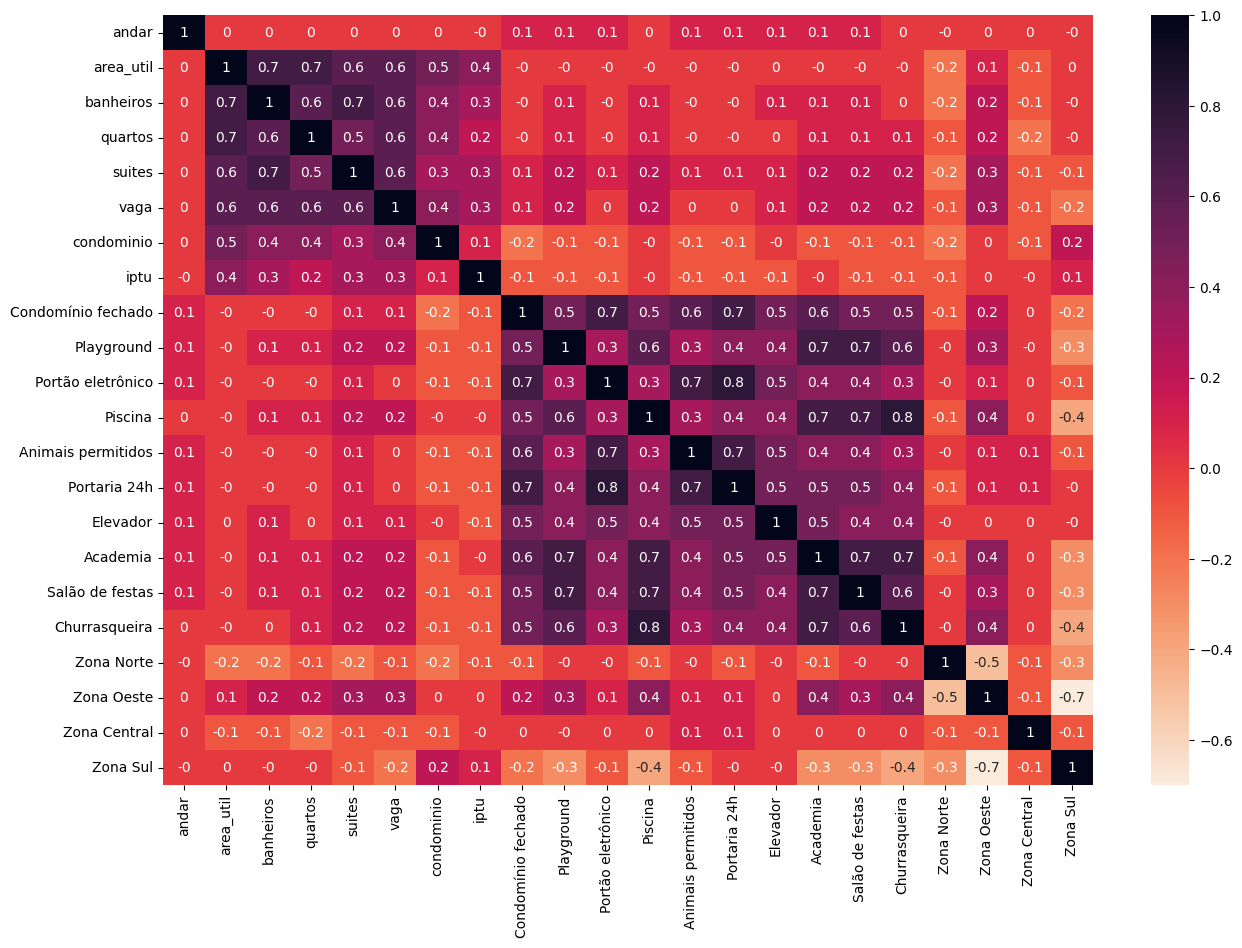

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

matriz_correlacao = pd.DataFrame(matriz_correlacao, columns=X, index=X)

plt.figure(figsize=(15, 10))
paleta = sns.color_palette("rocket_r", as_cmap=True)
sns.heatmap(matriz_correlacao.round(1), annot=True, cmap=paleta)

### Segue do mapa que qualidades que cada casa tem estão fortemente correlacionadas e que para benefícios que outras casas tem estão desde fracamente correlacionadas à fortemente correlacionadas.

### Por outro lado, qualidades e benefícions não apresentam correlação entre elas. Outra caracteristica importante que o preço de condomínio, iptu e zona da cidade quase não se correlacionam com ninguém.

In [47]:
df_processo.select('valor').summary().show()

+-------+------------------+
|summary|             valor|
+-------+------------------+
|  count|             63458|
|   mean|1196269.2363295408|
| stddev|1253269.8464567757|
|    min|           15000.0|
|    25%|          450000.0|
|    50%|          795000.0|
|    75%|         1490000.0|
|    max|            1.39E7|
+-------+------------------+



# Dado que a média e o desvio padrão da coluna `valor` estão muit altos enquanto que a mediana não ultrapassa 800 mil, utilizaremos o modelo de Regressão de Floresta de Árvores de Decisão para se adequar a bruscas mudanças.

In [48]:
from pyspark.ml.regression import RandomForestRegressor

In [49]:
treino, teste = df_processo.randomSplit([0.7, 0.3], seed=390)
treino.count()

44377

In [50]:
teste.count()

19081

In [51]:
rfr = RandomForestRegressor(featuresCol='features', labelCol='valor')
modelo = rfr.fit(treino)

In [52]:
previsao = modelo.transform(treino)
previsao.show(20)

+--------------------+---------+------------------+
|            features|    valor|        prediction|
+--------------------+---------+------------------+
|(22,[0,1,2,3,4,5,...|1330000.0|1387468.5800941058|
|(22,[0,1,2,3,4,5,...| 110000.0| 411282.8824102791|
|(22,[0,1,2,3,4,5,...|1320000.0|1325507.8316661082|
|(22,[0,1,2,3,4,5,...| 175000.0| 411282.8824102791|
|(22,[0,1,2,3,4,5,...| 983323.0|1660096.6639881574|
|(22,[0,1,2,3,4,5,...| 430000.0| 600321.2515543508|
|(22,[0,1,2,3,4,5,...|3200000.0| 2752222.677080713|
|(22,[0,1,2,3,4,5,...| 678000.0| 876198.2616153561|
|(22,[0,1,2,3,4,5,...| 220000.0| 430128.5044075319|
|(22,[0,1,2,3,4,5,...| 659000.0| 815638.0602664661|
|(22,[0,1,2,3,4,5,...| 600000.0| 886613.0408236347|
|(22,[0,1,2,3,4,5,...|1250000.0|1199208.7523680115|
|(22,[0,1,2,3,4,5,...|2100000.0| 986925.5927667136|
|(22,[0,1,2,3,4,5,...|2800000.0|1399585.0036260074|
|(22,[0,1,2,3,4,5,...|2900000.0| 2181545.916006332|
|(22,[0,1,2,3,4,5,...|1725000.0| 2653607.468204052|
|(22,[0,1,2,

## Faremos agora a avaliação do nosso modelo

In [53]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(
    labelCol="valor", predictionCol="prediction", metricName="rmse"
)
evaluator_r2 = RegressionEvaluator(
    labelCol="valor", predictionCol="prediction", metricName="r2"
)

rmse = evaluator_rmse.evaluate(previsao)
r2 = evaluator_r2.evaluate(previsao)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

RMSE: 639480.92
R²: 0.734


### Para o treino ele foi concideravelmente bem, vamos avaliar para o teste, porém não podemos afirmar que os preços estão coincidindo bem com os valores reais, uma vez que o RMSE está muito alto para casas de 150 mil para mais de 1 milhão.

In [54]:
previsao_teste = modelo.transform(teste)

rmse = evaluator_rmse.evaluate(previsao_teste)
r2 = evaluator_r2.evaluate(previsao_teste)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

RMSE: 663308.01
R²: 0.733


### Novamente tivemos bons resultados, mas ressalva novamente no caso do RMSE.

# Antes de finalizarmos por aqui, faremos um ajuste nos hiperparâmetros e testatemos um outro modelo para a previsão. Além do mais, para reduzir o erro entre os valores, aplicaremos uma função logarítimica nos valores.

In [55]:
df_processo = df_processo.withColumn('log(valor)', f.log(df_processo['valor']))
df_processo.show()

+--------------------+---------+------------------+
|            features|    valor|        log(valor)|
+--------------------+---------+------------------+
|(22,[1,2,3,4,5,6,...| 385000.0| 12.86099861326992|
|[17.0,56.0,2.0,2....| 436098.0|12.985622267716238|
|(22,[1,2,3,4,5,6,...| 615000.0|13.329377546788654|
|[0.0,194.0,5.0,4....|2900000.0|14.880221294956703|
|(22,[0,1,2,3,4,5,...|1050000.0|13.864300722133706|
|(22,[1,2,3,4,5,6,...| 990000.0|13.805460222110773|
|(22,[1,2,3,4,5,6,...| 400000.0| 12.89921982609012|
|[6.0,78.0,2.0,2.0...| 920000.0|13.732128949025222|
|(22,[1,2,3,6,7,13...| 750000.0|13.527828485512494|
|(22,[1,2,3,6,7,14...| 999230.0|13.814740261362008|
|(22,[1,2,3,4,6,7,...|1300000.0|14.077874822431765|
|[9.0,210.0,3.0,3....|1420000.0|14.166167429577444|
|[0.0,178.0,4.0,4....|2700000.0|14.808762330974558|
|(22,[0,1,2,3,6,7,...|1800000.0|14.403297222866392|
|[0.0,86.0,3.0,2.0...| 599000.0|13.303016877097587|
|(22,[1,2,3,5,6,7,...| 820000.0|13.617059619240436|
|(22,[1,2,3,

In [56]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

rfr_cross = RandomForestRegressor(featuresCol='features', labelCol='log(valor)')

grid = (ParamGridBuilder().addGrid(rfr_cross.maxDepth, [5, 10])\
                         .addGrid(rfr_cross.numTrees, [10])
                         .build())

cross_validation = CrossValidator(estimator=rfr_cross,\
                                  estimatorParamMaps=grid,\
                                  evaluator=RegressionEvaluator(labelCol='log(valor)'),\
                                  numFolds=5,\
                                  seed=390)

modelo_cross = cross_validation.fit(df_processo)

In [57]:
modelo_best = modelo_cross.bestModel
predicoes = modelo_best.transform(df_processo)
predicoes = predicoes.withColumn('prediction', f.exp(predicoes['prediction']))

avaliador = RegressionEvaluator(labelCol="valor", predictionCol="prediction")

r2 = avaliador.evaluate(predicoes, {avaliador.metricName: "r2"})
rmse = avaliador.evaluate(predicoes, {avaliador.metricName: "rmse"})

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

RMSE: 534792.27
R2: 0.818


### Como foi visto a R2 e o RMSE foram melhorados e apesar de um RMSE ainda muito alto, deve-se ressaltar que os valores das nossas casas são na casas dos milhares e sua média ultrapassa 1 milhão, logo obtivemos bons resultados.

### Neste momento utilizaremos o modelo Gradient-Boostes Tree Regression.

In [58]:
from pyspark.ml.regression import GBTRegressor

gbtr = GBTRegressor(featuresCol='features', labelCol='log(valor)')

In [59]:
treino, teste = df_processo.randomSplit([0.7, 0.3], seed=390)

modelo = gbtr.fit(treino)

In [60]:
predicao_treino = modelo.transform(treino)
predicao_treino = predicao_treino.withColumn('prediction', f.exp(predicao_treino['prediction']))

In [61]:
r2 = avaliador.evaluate(predicao_treino, {avaliador.metricName: "r2"})
rmse = avaliador.evaluate(predicao_treino, {avaliador.metricName: "rmse"})

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

RMSE: 609552.95
R2: 0.758


### Para o treino tivemos um resultado razoavelmente melhor que a Random Forest

In [62]:
predicao_teste = modelo.transform(teste)
predicao_teste = predicao_teste.withColumn('prediction', f.exp(predicao_teste['prediction']))

In [63]:
r2 = avaliador.evaluate(predicao_teste, {avaliador.metricName: "r2"})
rmse = avaliador.evaluate(predicao_teste, {avaliador.metricName: "rmse"})

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

RMSE: 633559.75
R2: 0.757


### Já para o teste, apesar do R2 ser melhor que no treino, o RMSE está levemente maior, porém melhor que no Random Forest.

### Por fim, vamos melhorar os hiperparâmetros.

In [ ]:
grid_gbt = ParamGridBuilder().addGrid(gbtr.maxDepth, [5, 10])\
                             .addGrid(gbtr.stepSize, [0.07])\
                             .addGrid(gbtr.maxIter, [20])\
                             .build()

cross_gbt = CrossValidator(estimator=gbtr,
                           estimatorParamMaps=grid_gbt,\
                           evaluator=RegressionEvaluator(labelCol='log(valor)'),\
                           numFolds=5,\
                           seed=390)

modelo_cross_gbt = cross_gbt.fit(df_processo)

In [ ]:
gbtr_best = modelo_cross_gbt.bestModel

predicoes_gbt = gbtr_best.transform(df_processo)

predicoes_gbt = predicoes_gbt.withColumn('prediction', f.exp(predicoes_gbt['prediction']))
predicoes_gbt.show()

In [ ]:
r2 = avaliador.evaluate(predicoes_gbt, {avaliador.metricName: "r2"})
rmse = avaliador.evaluate(predicoes_gbt, {avaliador.metricName: "rmse"})

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

### Finalmente quando melhorado os hiperparâmetros conseguimos o melhor resultado até o momento, com R2 = 0.87 e RMSE = 453000, concluindo o aprendizado do nosso melhor modelo.